# Problema


En este problema, construiremos un modelo de clasificación para predecir si un tumor de mama es maligno o benigno. Estos modelos suelen ser útiles, por ejemplo, para asistir en el diagnóstico médico temprano del cáncer de mama.

Los datos para este problema se encuentran en el archivo wdbc.data. La primera columna indica el ID del paciente, la segunda columna indica el diagnóstico (M = Maligno, B = Benigno), y las columnas restantes contienen 30 características numéricas.

## Hipótesis
Los tumores malignos presentan mayor radio, área y concavidad que los benignos,
y estas diferencias son suficientes para construir un clasificador de alta precisión.

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [172]:
# Nombres de columnas
columns = ['id', 'diagnosis',
           'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
           'smoothness_mean', 'compactness_mean', 'concavity_mean',
           'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
           'radius_se', 'texture_se', 'perimeter_se', 'area_se',
           'smoothness_se', 'compactness_se', 'concavity_se',
           'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
           'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
           'smoothness_worst', 'compactness_worst', 'concavity_worst',
           'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

# Cargar dataset
df = pd.read_csv("https://raw.githubusercontent.com/Pinuer/WDBC-Grupo8/main/wdbc.data", header=None, names=columns)
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [173]:
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [174]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0


In [175]:
# Verificación de registros duplicados
n_dup = df.duplicated().sum()
print(f"Registros duplicados: {n_dup}")
if n_dup == 0:
    print("No hay registros duplicados en el dataset.")
else:
    df = df.drop_duplicates()
    print(f"Se eliminaron {n_dup} registros duplicados.")

Registros duplicados: 0
No hay registros duplicados en el dataset.


In [176]:
# Eliminación de columna ID (no aporta información predictiva)
df = df.drop(columns=['id'])
print(f"Columna id eliminada")

Columna id eliminada


In [177]:
# Estadísticas descriptivas
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [178]:
# Mediana, Maximo, Minimo, Media y desviación estándar de las primeras 10 features
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
            'smoothness_mean', 'compactness_mean', 'concavity_mean',
            'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean']

for col in features:
    print(f"{col}:")
    print(f"   Media:             {df[col].mean():.4f}")
    print(f"   Mediana:           {df[col].median():.4f}")
    print(f"   Desviación std:    {df[col].std():.4f}")
    print(f"   MAX:    {df[col].max():.4f}")
    print(f"   MIN:    {df[col].min():.4f}")
    print()

radius_mean:
   Media:             14.1273
   Mediana:           13.3700
   Desviación std:    3.5240
   MAX:    28.1100
   MIN:    6.9810

texture_mean:
   Media:             19.2896
   Mediana:           18.8400
   Desviación std:    4.3010
   MAX:    39.2800
   MIN:    9.7100

perimeter_mean:
   Media:             91.9690
   Mediana:           86.2400
   Desviación std:    24.2990
   MAX:    188.5000
   MIN:    43.7900

area_mean:
   Media:             654.8891
   Mediana:           551.1000
   Desviación std:    351.9141
   MAX:    2501.0000
   MIN:    143.5000

smoothness_mean:
   Media:             0.0964
   Mediana:           0.0959
   Desviación std:    0.0141
   MAX:    0.1634
   MIN:    0.0526

compactness_mean:
   Media:             0.1043
   Mediana:           0.0926
   Desviación std:    0.0528
   MAX:    0.3454
   MIN:    0.0194

concavity_mean:
   Media:             0.0888
   Mediana:           0.0615
   Desviación std:    0.0797
   MAX:    0.4268
   MIN:    0.0000

conc

In [179]:
min_val = df.drop(columns=["diagnosis"]).min().min()
max_val = df.drop(columns=["diagnosis"]).max().max()

print(f"Features - mínimo: {min_val}, máximo: {max_val}")

if min_val > 0:
    print("Todo ok")
else:
    n_antes = len(df)
    df = df[(df.drop(columns=["diagnosis"]) > 0).all(axis=1)]
    print(f"Se eliminaron {n_antes - len(df)} registros con valores <= 0")

Features - mínimo: 0.0, máximo: 4254.0
Se eliminaron 13 registros con valores <= 0


In [180]:
# Comparación de medias por clase
medias = df.groupby('diagnosis')[['radius_mean','area_mean','concavity_mean',
                                   'perimeter_mean','compactness_mean']].mean().T
medias.columns = ['Benigno', 'Maligno']
medias['Diferencia %'] = ((medias['Maligno'] - medias['Benigno']) / medias['Benigno'] * 100).round(1)
print(medias.round(4).to_string())

                   Benigno   Maligno  Diferencia %
radius_mean        12.2499   17.4628          42.6
area_mean         469.8276  978.3764         108.2
concavity_mean      0.0478    0.1608         236.4
perimeter_mean     78.7911  115.3654          46.4
compactness_mean    0.0813    0.1452          78.5


## EDA

In [181]:
# Distribución de clases con porcentajes
counts = df['diagnosis'].value_counts()
porcentajes = df['diagnosis'].value_counts(normalize=True) * 100

print(counts)
print()
print("Porcentaje")
print(porcentajes.round(1))

diagnosis
B    344
M    212
Name: count, dtype: int64

Porcentaje
diagnosis
B    61.9
M    38.1
Name: proportion, dtype: float64


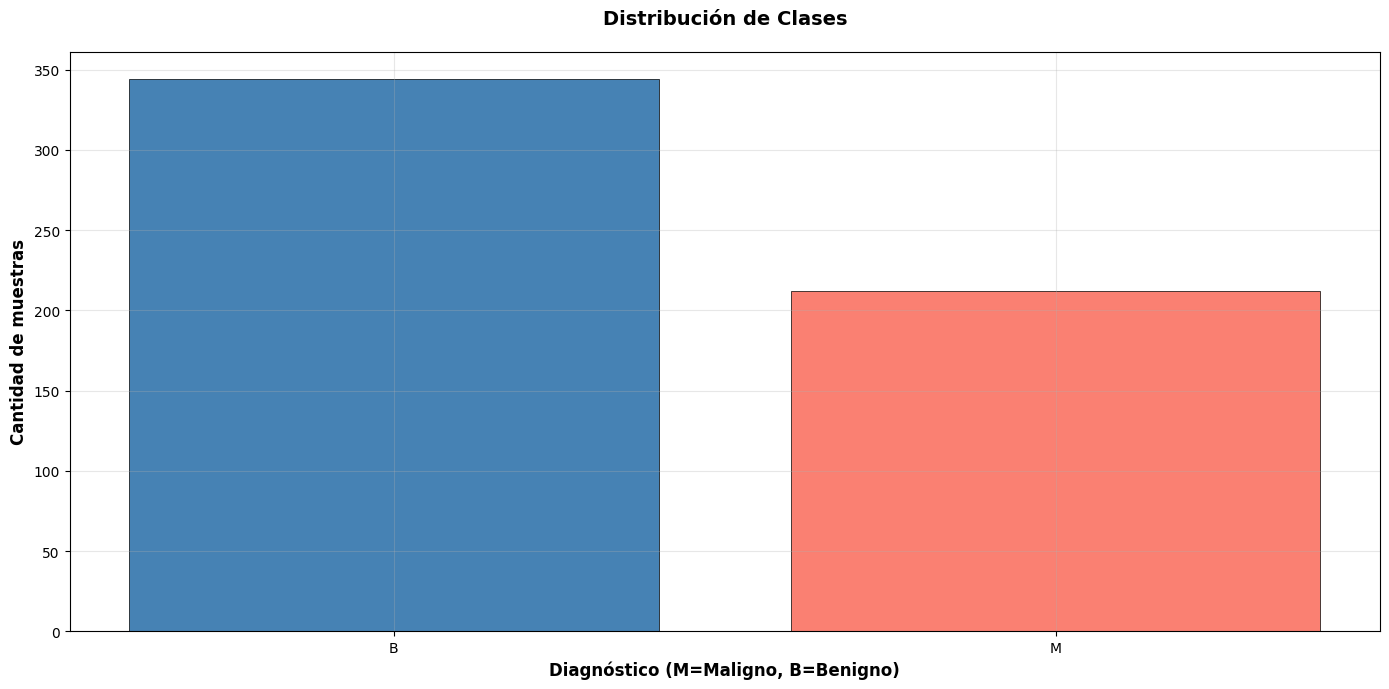

In [182]:
fig, ax = plt.subplots(figsize=(14, 7))
counts = df['diagnosis'].value_counts()
ax.bar(counts.index, counts.values, color=["steelblue", "salmon"],
       edgecolor="black", linewidth=0.5)
ax.set_xlabel("Diagnóstico (M=Maligno, B=Benigno)", fontsize=12, fontweight="bold")
ax.set_ylabel("Cantidad de muestras", fontsize=12, fontweight="bold")
ax.set_title("Distribución de Clases", fontsize=14, fontweight="bold", pad=20)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

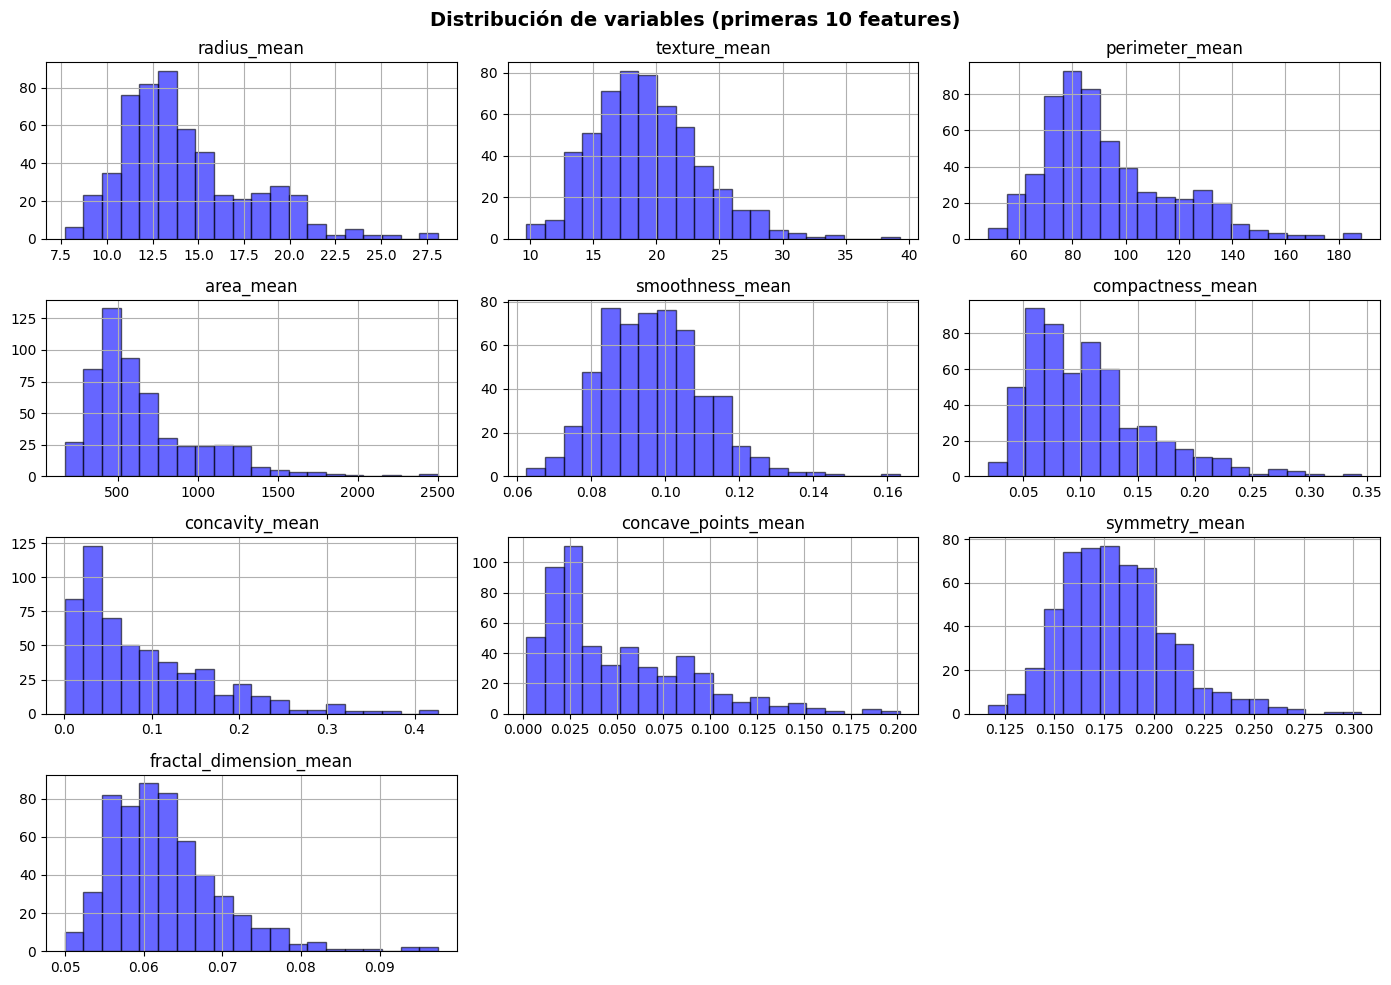

In [183]:
# Distribución de variables
df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean']].hist(bins=20, color="blue", edgecolor="black", alpha=0.6, figsize=(14, 10))
plt.suptitle("Distribución de variables (primeras 10 features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

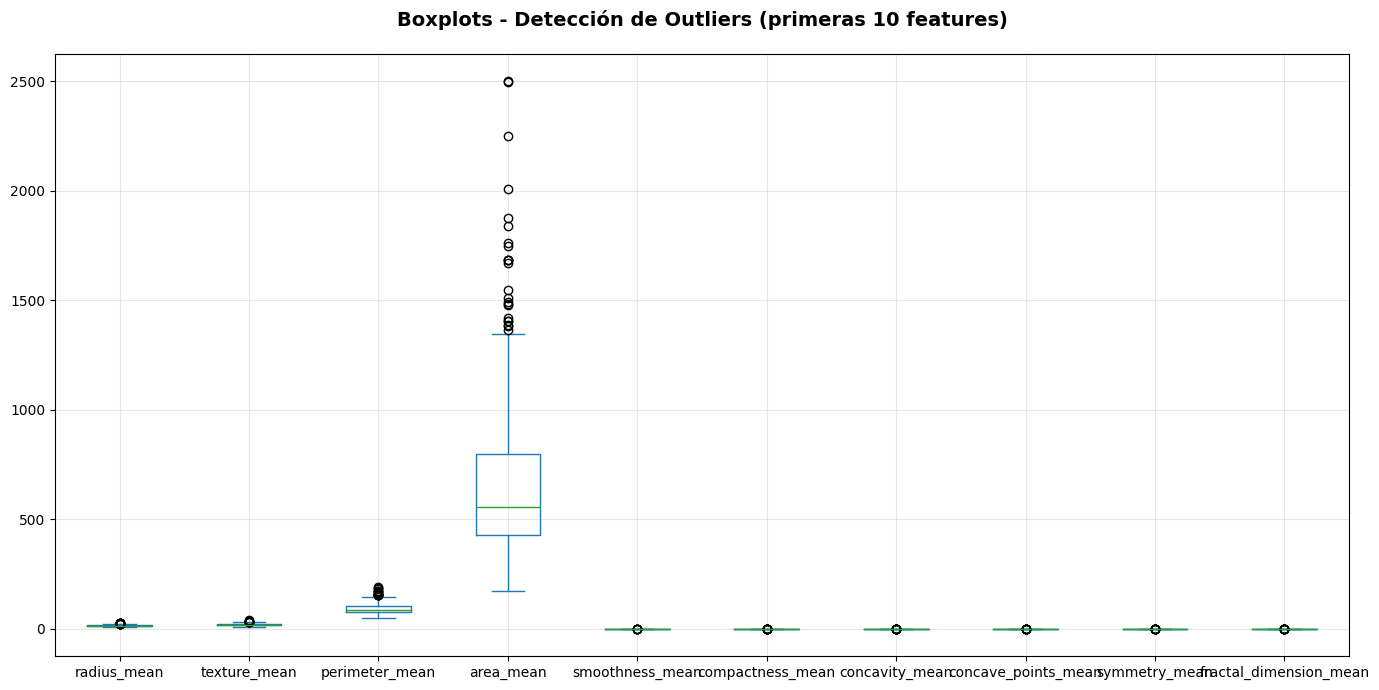

In [184]:
# Detección de Outliers
fig, ax = plt.subplots(figsize=(14, 7))
df[["radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean"]].plot(
    kind="box", ax=ax)
ax.set_title("Boxplots - Detección de Outliers (primeras 10 features)", fontsize=14, fontweight="bold", pad=20)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Separación de Clases


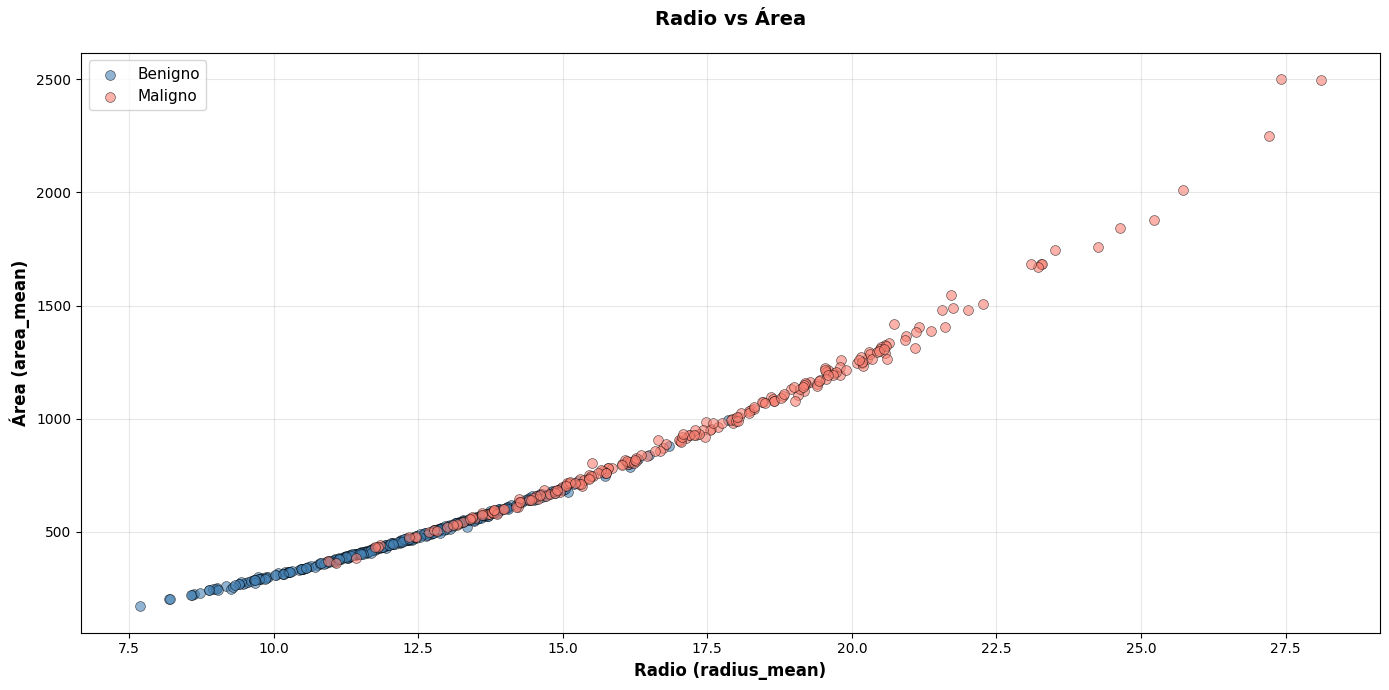

In [185]:
# Crear figura
fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(df[df['diagnosis'] == 'B']['radius_mean'],
           df[df['diagnosis'] == 'B']['area_mean'],
           alpha=0.6, s=50, color="steelblue", edgecolor='black', linewidth=0.5, label="Benigno")
ax.scatter(df[df['diagnosis'] == 'M']['radius_mean'],
           df[df['diagnosis'] == 'M']['area_mean'],
           alpha=0.6, s=50, color="salmon", edgecolor='black', linewidth=0.5, label="Maligno")
ax.set_xlabel("Radio (radius_mean)", fontsize=12, fontweight="bold")
ax.set_ylabel("Área (area_mean)", fontsize=12, fontweight="bold")
ax.set_title("Radio vs Área", fontsize=14, fontweight="bold", pad=20)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

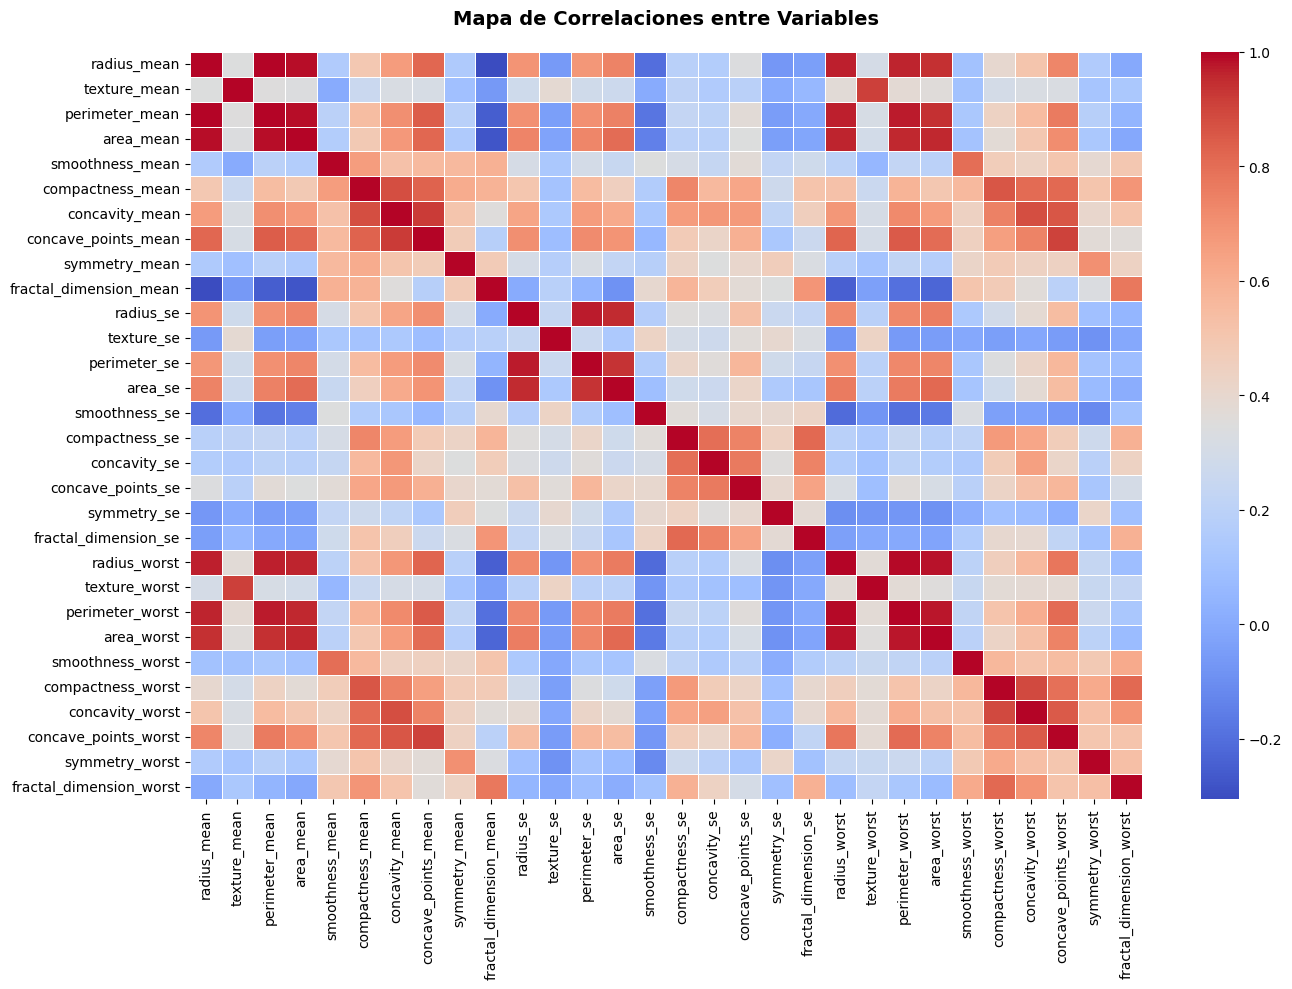

radius_mean        1.000000
perimeter_mean     0.997764
area_mean          0.988084
radius_worst       0.968670
perimeter_worst    0.964066
area_worst         0.941570
Name: radius_mean, dtype: float64


In [186]:
# Correlaciones entre variables
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(df.drop(columns=["diagnosis"]).corr(),
            cmap="coolwarm", ax=ax, linewidths=0.5)
ax.set_title("Mapa de Correlaciones entre Variables", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

# Top correlaciones con radius_mean
corr = df.drop(columns=["diagnosis"]).corr()
print(corr['radius_mean'].sort_values(ascending=False).head(6))

In [187]:
print(corr['area_mean']['perimeter_mean'])
print(corr['radius_mean']['area_mean'])
print(corr['radius_mean']['perimeter_mean'])

0.9871877263211379
0.988083790101215
0.9977641813023111


## Conclusiones del EDA

- **Desbalance de clases:** El dataset contiene un 61,9% de tumores benignos y 38,1% malignos, lo que confirma un leve desbalance.
- **Outliers:** Se identificaron valores atípicos principalmente en area_mean y perimeter_mean, variables con alta varianza.
- **Correlaciones:** Radio, perímetro y área presentan correlaciones mayores a 0.99 entre sí, lo que indica redundancia de información.
- **Separación de clases:** Los tumores malignos tienden a tener mayor radio y área, lo que confirma la hipótesis planteada.
- **Siguiente paso:** Entrenar modelos de clasificación usando estas variables para predecir el diagnóstico.
